In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
from sklearn import metrics
import multiprocessing as mp
from STWaveGraph.STWaveGraph import STWaveGraph
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
import rpy2

In [3]:
dataset = '151673'
n_clusters = 5 if dataset in ['151669', '151670', '151671', '151672'] else 7
file_fold = '/root/workspace/STWaveGraph-main/Data/DLPFC/' + str(dataset) #please replace 'file_fold' with the download path
adata = sc.read_visium(file_fold, count_file='filtered_feature_bc_matrix.h5', load_images=True)
adata.var_names_make_unique()

/opt/conda/envs/SpatioFrep/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


73:600:3500:random seed: 6497
6382:0.671
76:seed: 5549:0.603
510:seed: 8951:0.516

In [ ]:
model = STWaveGraph(
    adata=adata,
    n_clusters=n_clusters,
    device=device,

    n_top_genes=2500,
    pca_dim=40,
    n_neighbors_spatial=6,
    expr_power=1.4,

    pretrain_epochs=250,
    finetune_epochs=200,

    lambda_rec=0.3,
    lambda_ssl=0.5,
    lambda_smooth=0.015,
    lambda_kl=1.2,
    lambda_q_cons=0.3,      
    lambda_balance=0.0,
    lambda_boundary=0.25,

    refine_iters=1
)
adata = model.train(verbose=True)

========== Stage 1: Representation Pretraining ==========


100%|██████████| 250/250 [00:21<00:00, 11.55it/s]


========== Initialize Cluster Centers ==========
========== Stage 2: Clustering Finetuning ==========


 26%|██▌       | 51/200 [00:04<00:13, 10.88it/s]

[Finetune] Epoch 50/200 | loss=0.8324 | rec=1.8582 | ssl=0.2922 | smooth=0.3750 | kl=0.0592 | balance=0.0010 | bd=0.2071 | extra_reg_on=1


...

[Finetune] Epoch 100/200 | loss=0.7731 | rec=1.7298 | ssl=0.2343 | smooth=0.3815 | kl=0.0666 | balance=0.0012 | bd=0.2043 | extra_reg_on=1


 76%|███████▌  | 151/200 [00:13<00:04, 11.21it/s]

[Finetune] Epoch 150/200 | loss=0.7231 | rec=1.6149 | ssl=0.1894 | smooth=0.3770 | kl=0.0720 | balance=0.0014 | bd=0.2060 | extra_reg_on=1


100%|██████████| 200/200 [00:18<00:00, 11.03it/s]


[Finetune] Epoch 200/200 | loss=0.6819 | rec=1.5142 | ssl=0.1607 | smooth=0.3715 | kl=0.0744 | balance=0.0015 | bd=0.2084 | extra_reg_on=1
fitting ...
  |======================================================================| 100%


In [7]:
# add ground_truth
df_meta = pd.read_csv(file_fold + '/metadata.tsv', sep='\t')
df_meta_layer = df_meta['layer_guess']
adata.obs['ground_truth'] = df_meta_layer.values

In [8]:
adata

AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'pred_domain_raw', 'pred_domain', 'ground_truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatial', 'hvg', 'log1p', 'cluster_method_used', 'cluster_pca_dim', 'mclust_model', 'regularization_warmup_epochs'
    obsm: 'spatial', 'emb', 'model_q', 'soft_assign'

In [9]:
adata.obsm['emb']

array([[-0.0266559 ,  0.0890869 ,  0.11051243, ...,  0.11996577,
         0.02181283,  0.06646436],
       [ 0.01740721,  0.12376293, -0.0742759 , ...,  0.11334141,
         0.23465946, -0.00673181],
       [-0.11493549,  0.03582654, -0.08764949, ..., -0.11050358,
        -0.13548745,  0.11241684],
       ...,
       [-0.01636612, -0.03976671, -0.05929824, ...,  0.10699219,
        -0.02186489, -0.04122569],
       [-0.09105229, -0.09637348, -0.03464735, ...,  0.03310168,
        -0.054651  , -0.03806112],
       [-0.10179194,  0.05108098,  0.09481074, ...,  0.09520963,
         0.0342925 ,  0.05098459]], dtype=float32)

In [10]:
# filter out NA nodes
adata = adata[~pd.isnull(adata.obs['ground_truth'])]

# calculate metric ARI
ARI = metrics.adjusted_rand_score(adata.obs['pred_domain'], adata.obs['ground_truth'])
adata.uns['ARI'] = ARI

print('Dataset:', dataset)
print('ARI:', ARI)

/opt/conda/envs/SpatioFrep/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


Dataset: 151673
ARI: 0.6569714058311509


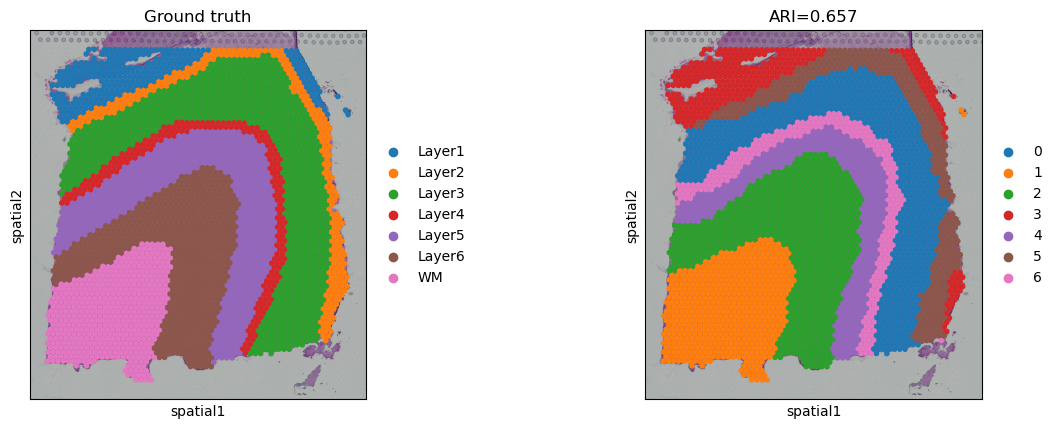

In [11]:
sc.pl.spatial(
    adata,
    img_key="hires",
    color=["ground_truth", "pred_domain"],
    title=["Ground truth", f"ARI={ARI:.3f}"],
    spot_size=150,
    show=True
)